<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/Learning%20and%20Optimization/Dropout_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Subset,DataLoader,random_split
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
epochs=100
start_epoch=0
learning_rate=1e-3
batch_size=128
best_acc=0
device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_dataset = Subset(train_dataset, range(1000))

#val_size = len(test_dataset)
#train_size = len(train_dataset) - val_size
#train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [ ]:
class PartNet(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(PartNet, self).__init__()
    self.net=nn.Sequential(
        nn.Linear(in_channels,out_channels),
        nn.ReLU(inplace=True),
        nn.Linear(out_channels,out_channels),
        nn.ReLU(inplace=True),
        nn.Linear(out_channels,out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self,x):
    return self.net(x)

In [ ]:
class DropoutNet(nn.Module):
  def __init__(self,output=10,device='cpu'):
    super(DropoutNet, self).__init__()
    self.device=device

    self.net1=PartNet(784,512)
    self.dropout1=nn.Dropout(0.5)
    self.net2=PartNet(512,512)
    self.dropout2=nn.Dropout(0.5)
    self.net3=nn.Linear(512,output)

  def forward(self,x):
    x=x.view(x.size(0),-1)
    x=self.net1(x)
    x=self.dropout1(x)
    x=self.net2(x)
    x=self.dropout2(x)
    x=self.net3(x)
    return x


In [ ]:
class SimpleNet(nn.Module):
  def __init__(self,output=10,device='cpu'):
    super(SimpleNet, self).__init__()
    self.device=device

    self.net1=PartNet(784,512)
    self.net2=PartNet(512,512)
    self.net3=nn.Linear(512,output)

  def forward(self,x):
    x=x.view(x.size(0),-1)
    x=self.net1(x)
    x=self.net2(x)
    x=self.net3(x)
    return x

In [ ]:
torch.manual_seed(42)
model1=SimpleNet(output=10,device=device).to(device)
torch.manual_seed(42)
model2=DropoutNet(output=10,device=device).to(device)
optimizer1=torch.optim.AdamW(model1.parameters(),lr=learning_rate)
optimizer2=torch.optim.AdamW(model2.parameters(),lr=learning_rate)
criterion=nn.CrossEntropyLoss()

In [ ]:
train_acc_list = [[],[]]
test_acc_list = [[],[]]

In [ ]:
if os.path.exists('/content/drive/MyDrive/dropout.pth'):
  checkpoint = torch.load('/content/drive/MyDrive/dropout.pth')
  train_acc_list = checkpoint['train_acc_list']
  test_acc_list = checkpoint['test_acc_list']
  model1.load_state_dict(checkpoint['model_state_dict1'])
  model2.load_state_dict(checkpoint['model_state_dict2'])
  optimizer1.load_state_dict(checkpoint['optimizer_state_dict1'])
  optimizer2.load_state_dict(checkpoint['optimizer_state_dict2'])
  start_epoch = checkpoint['epoch'] + 1

In [ ]:
for epoch in tqdm(range(start_epoch,epochs),desc="Epoch"):
  model1.train()
  model2.train()
  for x,t in tqdm(train_loader,desc="Iteration",leave=False):
    x, t = x.to(device), t.to(device)

    optimizer1.zero_grad()
    optimizer2.zero_grad()

    loss1 = criterion(model1(x), t)
    loss2 = criterion(model2(x), t)

    loss1.backward()
    loss2.backward()
    optimizer1.step()
    optimizer2.step()

  model1.eval()
  model2.eval()
  correct1 = 0
  correct2 = 0
  with torch.no_grad():
    for x, t in train_loader:
      x, t = x.to(device), t.to(device)
      correct1 += (model1(x).argmax(1) == t).sum().item()
      correct2 += (model2(x).argmax(1) == t).sum().item()

  train_acc1=correct1/len(train_dataset)
  train_acc2=correct2/len(train_dataset)
  train_acc_list[0].append(train_acc1)
  train_acc_list[1].append(train_acc2)

  correct1 = 0
  correct2 = 0
  with torch.no_grad():
    for x, t in test_loader:
      x, t = x.to(device), t.to(device)
      correct1 += (model1(x).argmax(1) == t).sum().item()
      correct2 += (model2(x).argmax(1) == t).sum().item()

  test_acc1=correct1/len(test_dataset)
  test_acc2=correct2/len(test_dataset)
  test_acc_list[0].append(test_acc1)
  test_acc_list[1].append(test_acc2)

  torch.save({
      'epoch': epoch,
      'train_acc_list': train_acc_list,
      'test_acc_list': test_acc_list,
      'model_state_dict1': model1.state_dict(),
      'optimizer_state_dict1': optimizer1.state_dict(),
      'model_state_dict2': model2.state_dict(),
      'optimizer_state_dict2': optimizer2.state_dict(),
  },'/content/drive/MyDrive/dropout.pth')

  #print("train acc with DO : "+str(train_acc1)+", without DO : "+str(train_acc2))
  #print("test acc with DO : "+str(test_acc1)+", without DO : "+str(test_acc2))

Epoch:   0%|          | 0/30 [00:00<?, ?it/s]

Iteration:   0%|          | 0/8 [00:00<?, ?it/s]

Iteration:   0%|          | 0/8 [00:00<?, ?it/s]

Iteration:   0%|          | 0/8 [00:00<?, ?it/s]

Iteration:   0%|          | 0/8 [00:00<?, ?it/s]

...

Iteration:   0%|          | 0/8 [00:00<?, ?it/s]

Iteration:   0%|          | 0/8 [00:00<?, ?it/s]

Iteration:   0%|          | 0/8 [00:00<?, ?it/s]

Iteration:   0%|          | 0/8 [00:00<?, ?it/s]

Iteration:   0%|          | 0/8 [00:00<?, ?it/s]

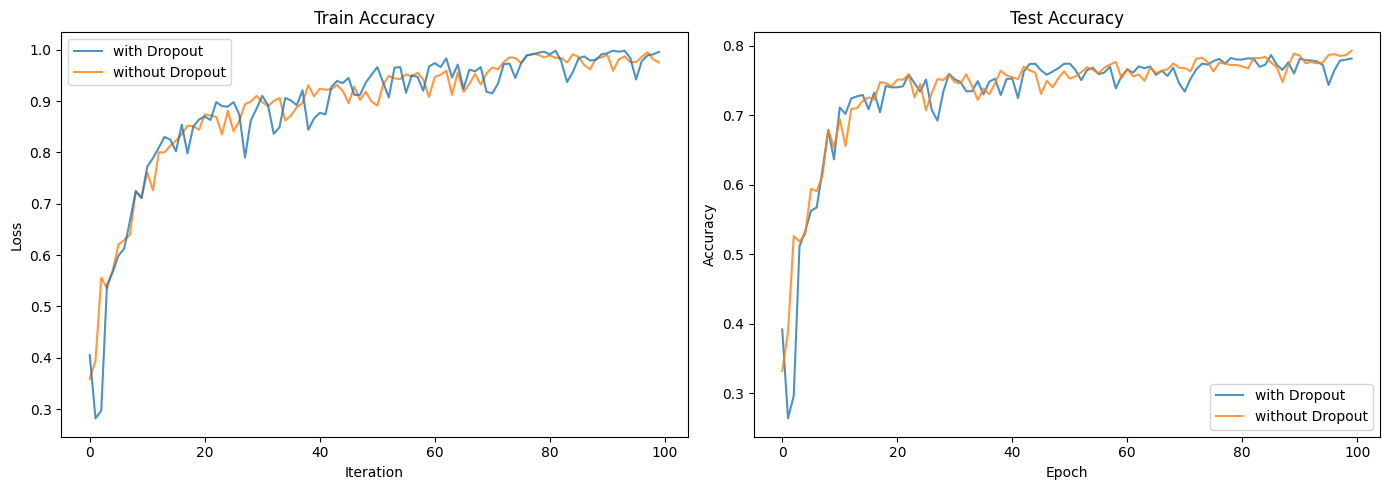

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(train_acc_list[0], label="with Dropout", alpha=0.8,zorder=2)
axes[0].plot(train_acc_list[1], label="without Dropout", alpha=0.8,zorder=1)
axes[0].set_title("Train Accuracy")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy 그래프
axes[1].plot(test_acc_list[0], label="with Dropout", alpha=0.8)
axes[1].plot(test_acc_list[1], label="without Dropout", alpha=0.8)
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()